<a href="https://colab.research.google.com/github/Aman7747/Atri-AI-Submission/blob/main/fashion_mnist_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1
Download the Fashion-MNIST dataset and plot 1 sample image for each class as
shown in the grid below. Use "from keras. datasets import fashion_mnist" for getting
the Fashion MNIST dataset

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
import wandb



In [19]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 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


wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zda24m013 (zda24m013-iit-madras-zanzibar) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [20]:
# Initialize WandB
wandb.init(
    project="fashion_mnist_assignment",
    name="Q1_Class_Image_Visualization"
)

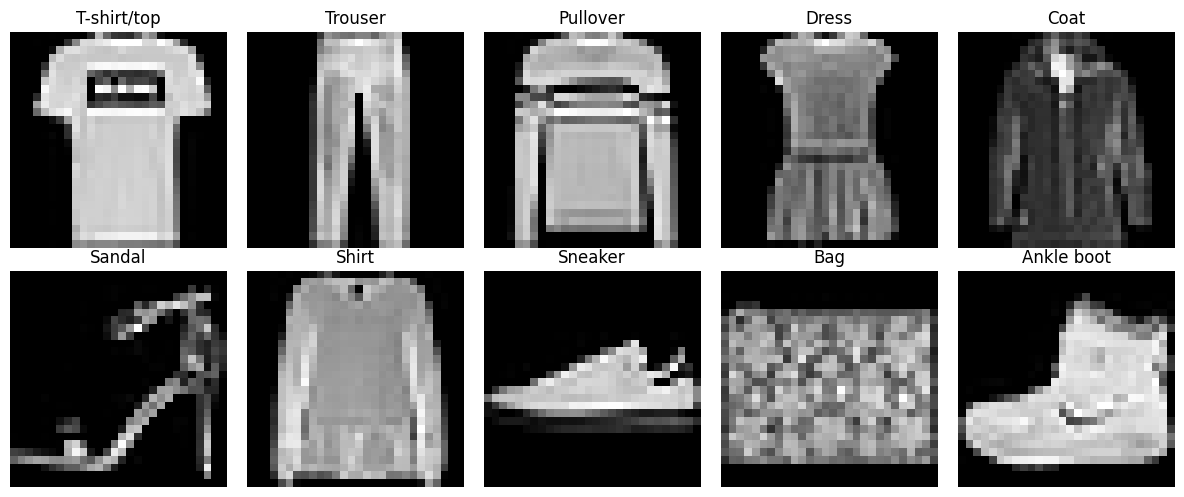

In [21]:
# plots for 1 sample image from each class

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
seen = set()

for img, label in zip(x_train, y_train):
    if label not in seen:
        ax = axes[label // 5, label % 5]
        ax.imshow(img, cmap="gray")
        ax.set_title(class_names[label])
        ax.axis("off")
        seen.add(label)
    if len(seen) == 10:
        break

wandb.log({
    "Fashion_MNIST_Samples": [
        wandb.Image(
            axes[i // 5, i % 5].images[0].get_array(),
            caption=class_names[i]
        )
        for i in range(10)
    ]
})
plt.tight_layout()
plt.show()

##Question 2
Implement a feedforward neural network that takes images from the Fashion-MNIST
data as input and outputs a probability distribution over the 10 classes.

In [24]:
import numpy as np

# Activation Functions

def sigmoid(x):
    return 1/(1+np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum()



In [25]:
# Weight Initialization

def init_weights(init_type, out_dim, in_dim):

    if init_type == "random":
        return np.random.randn(out_dim, in_dim) * 0.01

    elif init_type == "xavier":
        return np.random.randn(out_dim, in_dim) * np.sqrt(1/in_dim)





In [26]:
# Linear Forward

def linear_forward(h_prev, W, b):

    h_prev = h_prev.reshape(h_prev.shape[0], -1)

    z = np.dot(W, h_prev) + b

    cache = (h_prev, W, b)

    return z, cache

In [27]:
# Initialize Network

def init_network(X, hidden_layers, hidden_size, init_type):

    layers = [X.shape[0]]

    for _ in range(hidden_layers):
        layers.append(hidden_size)

    layers.append(10)

    np.random.seed(42)

    params = {}
    velocity = {}
    grads = {}

    L = len(layers)

    for l in range(1, L):

        params[f"W{l}"] = init_weights(
            init_type,
            layers[l],
            layers[l-1]
        )

        params[f"b{l}"] = np.zeros((layers[l], 1))

        velocity[f"W{l}"] = np.zeros((layers[l], layers[l-1]))
        velocity[f"b{l}"] = np.zeros((layers[l], 1))

        grads[f"dW{l}"] = np.zeros((layers[l], layers[l-1]))
        grads[f"db{l}"] = np.zeros((layers[l], 1))

    return params, velocity, grads

In [29]:
# Activation Forward

def act_forward(h_prev, W, b, act):

    z, linear_cache = linear_forward(h_prev, W, b)

    act_cache = z

    if act == "relu":
        h = relu(z)

    elif act == "sigmoid":
        h = sigmoid(z)

    elif act == "tanh":
        h = tanh(z)

    elif act == "softmax":
        h = softmax(z)

    return h, act_cache, linear_cache


In [30]:
# Full Forward Propagation

def forward_prop(X, params, act):

    h = X

    L = len(params)//2

    a_cache = []
    h_cache = [h]

    for l in range(1, L):

        h_prev = h

        h, a, lin = act_forward(
            h_prev,
            params[f"W{l}"],
            params[f"b{l}"],
            act
        )

        a_cache.append(a)
        h_cache.append(h)

    y_hat, a, lin = act_forward(
        h,
        params[f"W{L}"],
        params[f"b{L}"],
        act="softmax"
    )

    a_cache.append(a)
    h_cache.append(y_hat)

    return y_hat, h_cache, a_cache

# Question 3

Implement the backpropagation algorithm with support for the following optimisation functions:

- SGD  
- Momentum-based Gradient Descent  
- Nesterov Accelerated Gradient Descent (NAG)  
- RMSProp  
- Adam  
- Nadam

In [38]:
# One Hot Encoding

def one_hot_encoding(y, num_classes):

    vec = []

    for i in range(num_classes):

        if i == y:
            vec.append(1)

        else:
            vec.append(0)

    return np.asarray(vec)

In [39]:
# Derivative of Activation Functions

def activation_grad(z, act):

    if act == "relu":

        z[z <= 0] = 0
        z[z > 0] = 1

        return z

    elif act == "sigmoid":

        return sigmoid(z) * (1 - sigmoid(z))

    elif act == "tanh":

        return 1 - (tanh(z))**2


In [53]:
# Backpropagation

def backward_prop(h_cache, a_cache, params, y_hat, y, act, weight_decay, loss):

    y_onehot = []

    L = len(params)//2

    samples = y_hat.shape[1]

    classes = y_hat.shape[0]

    for i in range(samples):

        y_onehot.append(one_hot_encoding(y[i], classes))

    y_onehot = np.reshape(y_onehot,(classes, samples))

    # Loss derivative
    if loss == "cross_entropy":

        da = -(y_onehot - y_hat)

    elif loss == "mse":

        da = (y_hat - y_onehot)

    grads = {}

    # Backward loop
    for l in reversed(range(1, L+1)):

        dW = np.matmul( da, np.transpose(h_cache[l-1])) + 2 * weight_decay * params[f"W{l}"]

        db = da

        if l != 1:

            dh = np.dot(params[f"W{l}"].T, da)

            da = np.multiply( dh, activation_grad(a_cache[l-2], act))

        grads[f"dW{l}"] = dW
        grads[f"db{l}"] = db

    return grads

In [54]:
# SGD Optimizer

def sgd(params, grads, lr, L):

    for l in range(L):

        params[f"W{l+1}"] -= lr * grads[f"dW{l+1}"]
        params[f"b{l+1}"] -= lr * grads[f"db{l+1}"]

    return params

In [55]:
# Momentum Gradient Descent

def momentum(params, grads, lr, gamma, velocity, L):

    for l in range(L):

        velocity['W' + str(l+1)] = gamma * velocity['W' + str(l+1)] + lr * grads['dW' + str(l+1)]
        velocity['b' + str(l+1)] = gamma * velocity['b' + str(l+1)] + lr * grads['db' + str(l+1)]

        params['W' + str(l+1)] = params['W' + str(l+1)] - velocity['W' + str(l+1)]
        params['b' + str(l+1)] = params['b' + str(l+1)] - velocity['b' + str(l+1)]

    return params, velocity

In [56]:
# Nesterov Accelerated Gradient

def nag(params, lr, gamma, velocity, L):

    temp_params = {}

    for l in range(L):

        velocity['W' + str(l+1)] = gamma * velocity['W' + str(l+1)]
        velocity['b' + str(l+1)] = gamma * velocity['b' + str(l+1)]

        temp_params['W' + str(l+1)] = params['W' + str(l+1)] - velocity['W' + str(l+1)]
        temp_params['b' + str(l+1)] = params['b' + str(l+1)] - velocity['b' + str(l+1)]

    return temp_params, velocity

In [57]:
# RMSProp Optimizer

def rmsprop(params, lr, velocity, beta, eps, grads, L):

    for l in range(L):

        velocity['W' + str(l+1)] = beta * velocity['W' + str(l+1)] + (1-beta) * grads['dW' + str(l+1)]**2
        velocity['b' + str(l+1)] = beta * velocity['b' + str(l+1)] + (1-beta) * grads['db' + str(l+1)]**2

        params['W' + str(l+1)] = params['W' + str(l+1)] - (lr/np.sqrt(velocity['W' + str(l+1)] + eps)) * grads['dW' + str(l+1)]
        params['b' + str(l+1)] = params['b' + str(l+1)] - (lr/np.sqrt(velocity['b' + str(l+1)] + eps)) * grads['db' + str(l+1)]

    return params, velocity

In [58]:
# Adam Optimizer

def adam(params, lr, beta1, beta2, momentum, variance, eps, grads, L, t):

    import math

    m_hat = momentum.copy()

    v_hat = variance.copy()

    for l in range(L):

        momentum['W' + str(l+1)] = beta1 * momentum['W' + str(l+1)] + (1-beta1) * grads['dW' + str(l+1)]
        momentum['b' + str(l+1)] = beta1 * momentum['b' + str(l+1)] + (1-beta1) * grads['db' + str(l+1)]
        variance['W' + str(l+1)] = beta2 * variance['W' + str(l+1)] + (1-beta2) * grads['dW' + str(l+1)]**2
        variance['b' + str(l+1)] = beta2 * variance['b' + str(l+1)] + (1-beta2) * grads['db' + str(l+1)]**2

        m_hat['W' + str(l+1)] = momentum['W' + str(l+1)] / (1 - math.pow(beta1, t+1))
        m_hat['b' + str(l+1)] = momentum['b' + str(l+1)] / (1 - math.pow(beta1, t+1))
        v_hat['W' + str(l+1)] = variance['W' + str(l+1)] / (1 - math.pow(beta2, t+1))
        v_hat['b' + str(l+1)] = variance['b' + str(l+1)] / (1 - math.pow(beta2, t+1))

        params['W' + str(l+1)] = params['W' + str(l+1)] - (lr/(np.sqrt(v_hat['W' + str(l+1)] + eps))) * m_hat['W' + str(l+1)]
        params['b' + str(l+1)] = params['b' + str(l+1)] - (lr/(np.sqrt(v_hat['b' + str(l+1)] + eps))) * m_hat['b' + str(l+1)]

    return params, momentum, variance

In [59]:
# Nadam Optimizer

def nadam(params, lr, beta1, beta2, momentum, variance, eps, grads, L, t):

    import math

    m_hat = momentum.copy()

    v_hat = variance.copy()

    for l in range(L):

        momentum['W' + str(l+1)] = beta1 * momentum['W' + str(l+1)] + (1-beta1) * grads['dW' + str(l+1)]
        momentum['b' + str(l+1)] = beta1 * momentum['b' + str(l+1)] + (1-beta1) * grads['db' + str(l+1)]
        variance['W' + str(l+1)] = beta2 * variance['W' + str(l+1)] + (1-beta2) * grads['dW' + str(l+1)]**2
        variance['b' + str(l+1)] = beta2 * variance['b' + str(l+1)] + (1-beta2) * grads['db' + str(l+1)]**2

        m_hat['W' + str(l+1)] = momentum['W' + str(l+1)] / (1 - math.pow(beta1, t+1))
        m_hat['b' + str(l+1)] = momentum['b' + str(l+1)] / (1 - math.pow(beta1, t+1))
        v_hat['W' + str(l+1)] = variance['W' + str(l+1)] / (1 - math.pow(beta2, t+1))
        v_hat['b' + str(l+1)] = variance['b' + str(l+1)] / (1 - math.pow(beta2, t+1))

        nesterov_w = beta1 * m_hat['W' + str(l+1)] + ((1-beta1) * grads['dW' + str(l+1)]) / (1 - math.pow(beta1, t+1))
        nesterov_b = beta1 * m_hat['b' + str(l+1)] + ((1-beta1) * grads['db' + str(l+1)]) / (1 - math.pow(beta1, t+1))
        params['W' + str(l+1)] = params['W' + str(l+1)] - (lr/(np.sqrt(v_hat['W' + str(l+1)] + eps))) * nesterov_w
        params['b' + str(l+1)] = params['b' + str(l+1)] - (lr/(np.sqrt(v_hat['b' + str(l+1)] + eps))) * nesterov_b

    return params, momentum, variance